In [38]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
spark = SparkSession.builder.appName("modelling").config("spark.driver.memory", "12g").getOrCreate()

In [39]:
# read in the yellow taxi data from parquet file
yellow_taxi_cleaned_data = spark.read.parquet('cleaned_data/yellow_data.parquet')
yellow_taxi_cleaned_data.show(1)

+-------------------+------------+------------+-------+
|               date|PULocationID|total_amount|Borough|
+-------------------+------------+------------+-------+
|2023-05-01 00:33:13|         138|       51.65| Queens|
+-------------------+------------+------------+-------+
only showing top 1 row


# Preparing training data
In this section, we prepare the training data. This involves the following steps:
1. Aggregating the preprocessed yellow taxi data to the correct frequency and creating a value `total_amount`, corresponding to the earnings earned by all yellow taxis on a particular day at a particular zone.
2. Spatially join the yellow taxi data with the locations of the subway stations in NYC to obtain the `num_stations` column and later, `has_stations`. 
3. Adding another column `residential_density` via a similar spatial joining mechanism as what was done with the stations. Shapefiles are used here and preprocessing was done to remove `null` values for `residential_density`.
4. Calculating `trip_volume` from the preprocessed HVFHV dataset and then joining it to the yellow taxi data by `date` and `PULocationID`.
5. Adding a `log()` transform to `trip_volume` and `total_amount` due to their right skewed distributions.
6. The binary indicator column `isAirport` was also added.

In [40]:
# prepare the yellow taxi data for training
from utils import add_stations
# aggregate to daily
print('Shape before grouping by date and location:', (yellow_taxi_cleaned_data.count(), len(yellow_taxi_cleaned_data.columns)))
yellow_taxi_daily_earnings = (
    yellow_taxi_cleaned_data
    .withColumn("date", F.to_date("date"))
    .groupBy("date", "PULocationID", 'Borough')
    .agg(F.sum("total_amount").alias("daily_total_amount"))
    .orderBy("date")
)
print('Shape after grouping by date and location:', (yellow_taxi_daily_earnings.count(), len(yellow_taxi_daily_earnings.columns)))

print('Shape before adding stations:', (yellow_taxi_daily_earnings.count(), len(yellow_taxi_daily_earnings.columns)))
yellow_taxi_daily_earnings = add_stations(yellow_taxi_daily_earnings, spark)
print('Shape after adding stations:', (yellow_taxi_daily_earnings.count(), len(yellow_taxi_daily_earnings.columns)))

print('Shape before reading residential data:', None)
residential_data = spark.read.csv('cleaned_data/residential_data.csv', header=True, inferSchema=True)
print('Shape after reading residential data:', (residential_data.count(), len(residential_data.columns)))

print('Shape before adding residential_density:', (residential_data.count(), len(residential_data.columns)))
residential_data = residential_data.withColumn("residential_density", F.col("TotalResidentialUnits") / F.col("TotalNumBldgs"))
residential_data = residential_data.select('LocationID', 'residential_density')
print('Shape after calculating residential_density:', (residential_data.count(), len(residential_data.columns)))

print('Shape before joining with residential data:', (yellow_taxi_daily_earnings.count(), len(yellow_taxi_daily_earnings.columns)))
training_data = yellow_taxi_daily_earnings.join(residential_data, yellow_taxi_daily_earnings.PULocationID == residential_data.LocationID, 'left').drop('LocationID')
print('Shape after joining with residential data:', (training_data.count(), len(training_data.columns)))

# drop rows where residential_density is null
print('Shape', training_data.count(), ',', len(training_data.columns))
training_data.show(2)


Shape before grouping by date and location: (127565947, 4)


Shape after grouping by date and location: (252062, 4)


Shape before adding stations: (252062, 4)


Shape after adding stations: (252062, 5)
Shape before reading residential data: None
Shape after reading residential data: (239, 7)
Shape before adding residential_density: (239, 7)
Shape after calculating residential_density: (239, 2)


Shape before joining with residential data: (252062, 5)


Shape after joining with residential data: (252062, 6)


Shape 252062 , 6


+----------+------------+---------+------------------+------------+-------------------+
|      date|PULocationID|  Borough|daily_total_amount|num_stations|residential_density|
+----------+------------+---------+------------------+------------+-------------------+
|2023-05-01|         165| Brooklyn|            341.76|           3| 2.4132334581772783|
|2023-05-02|          79|Manhattan|41475.729999999974|           2| 16.148442272449604|
+----------+------------+---------+------------------+------------+-------------------+
only showing top 2 rows


In [41]:
training_data.sort('date', ascending=False)
# remove all areas that have NULL residential_density except with PULocationID 1, 132 or 138
print('Shape before filtering NULL residential_density:', (training_data.count(), len(training_data.columns)))
training_data = training_data.filter(~((F.col('residential_density').isNull()) & (~F.col('PULocationID').isin([1, 132, 138]))))
print('Shape after filtering NULL residential_density:', (training_data.count(), len(training_data.columns)))

# create a new column called isAirport that is 1 if PULocationID is 132, 1 or 138, else 0
print('Shape before adding isAirport:', (training_data.count(), len(training_data.columns)))
training_data = training_data.withColumn('isAirport', F.when(F.col('PULocationID').isin([132, 1, 138]), 1).otherwise(0))
print('Shape after adding isAirport:', (training_data.count(), len(training_data.columns)))

# replace null values in residential_density with 0
print('Shape before filling NULL residential_density:', (training_data.count(), len(training_data.columns)))
training_data = training_data.fillna({'residential_density': 0})
print('Shape after filling NULL residential_density:', (training_data.count(), len(training_data.columns)))


Shape before filtering NULL residential_density: (252062, 6)


Shape after filtering NULL residential_density: (240473, 6)


Shape before adding isAirport: (240473, 6)


Shape after adding isAirport: (240473, 7)


Shape before filling NULL residential_density: (240473, 7)


Shape after filling NULL residential_density: (240473, 7)


In [42]:
# prepare the fhvhv taxi data for training by extracting trip volume 
print('Shape before reading fhvhv data:', None)
fhvhv_taxi_cleaned_data = spark.read.parquet('cleaned_data/fhvhv_data.parquet')
print('Shape after reading fhvhv data:', (fhvhv_taxi_cleaned_data.count(), len(fhvhv_taxi_cleaned_data.columns)))

print('Shape before converting date:', (fhvhv_taxi_cleaned_data.count(), len(fhvhv_taxi_cleaned_data.columns)))
fhvhv_taxi_cleaned_data = fhvhv_taxi_cleaned_data.withColumn("date", F.to_date("date"))
print('Shape after converting date:', (fhvhv_taxi_cleaned_data.count(), len(fhvhv_taxi_cleaned_data.columns)))

print('Shape before grouping by date and location:', (fhvhv_taxi_cleaned_data.count(), len(fhvhv_taxi_cleaned_data.columns)))
fhvhv_trip_volume = (
    fhvhv_taxi_cleaned_data
    .groupBy("date", "PULocationID")
    .agg(F.count("*").alias("daily_trip_volume"))
    .orderBy("date")
)
print('Shape after grouping by date and location:', (fhvhv_trip_volume.count(), len(fhvhv_trip_volume.columns)))
fhvhv_trip_volume.show(1)

Shape before reading fhvhv data: None
Shape after reading fhvhv data: (821508685, 2)
Shape before converting date: (821508685, 2)
Shape after converting date: (821508685, 2)
Shape before grouping by date and location: (821508685, 2)


Shape after grouping by date and location: (320583, 3)


+----------+------------+-----------------+
|      date|PULocationID|daily_trip_volume|
+----------+------------+-----------------+
|2023-01-01|         217|              851|
+----------+------------+-----------------+
only showing top 1 row


In [43]:
# join the fhvhv_trip_volume to the training_data on date and PULocationID
print('Shape before joining fhvhv trip volume:', (training_data.count(), len(training_data.columns)))
training_data = training_data.join(
    fhvhv_trip_volume,
    on=["date", "PULocationID"],
    how='inner'
)
print('Shape after joining fhvhv trip volume:', (training_data.count(), len(training_data.columns)))
training_data.show(1)

Shape before joining fhvhv trip volume: (240473, 7)


Shape after joining fhvhv trip volume: (239434, 8)


+----------+------------+--------+------------------+------------+-------------------+---------+-----------------+
|      date|PULocationID| Borough|daily_total_amount|num_stations|residential_density|isAirport|daily_trip_volume|
+----------+------------+--------+------------------+------------+-------------------+---------+-----------------+
|2023-01-01|          11|Brooklyn|              42.6|           0| 2.4930684874818954|        0|              703|
+----------+------------+--------+------------------+------------+-------------------+---------+-----------------+
only showing top 1 row


In [44]:
print('Shape before feature engineering:', 
      (training_data.count(), len(training_data.columns)))

training_data_with_features_prefiltered = training_data

print('Shape after filtering values from target', 
      (training_data_with_features_prefiltered.count(), 
       len(training_data_with_features_prefiltered.columns)))

print('Shape before adding log_daily_total_amount:', 
      (training_data_with_features_prefiltered.count(), 
       len(training_data_with_features_prefiltered.columns)))

training_data_with_features_prefiltered = \
    training_data_with_features_prefiltered \
.withColumn("log_daily_total_amount", F.log1p("daily_total_amount"))

print('Shape after adding log_daily_total_amount:', 
      (training_data_with_features_prefiltered.count(), 
       len(training_data_with_features_prefiltered.columns)))

print('Shape before filtering null log_daily_total_amount:', 
      (training_data_with_features_prefiltered.count(), 
       len(training_data_with_features_prefiltered.columns)))
training_data_with_features_prefiltered = \
    training_data_with_features_prefiltered \
        .filter(F.col('log_daily_total_amount').isNotNull())
print('Shape after filtering null log_daily_total_amount:', 
      (training_data_with_features_prefiltered.count(), 
       len(training_data_with_features_prefiltered.columns)))

print('Shape before adding log_daily_trip_volume:', 
      (training_data_with_features_prefiltered.count(), 
       len(training_data_with_features_prefiltered.columns)))

training_data_with_features_prefiltered = \
    training_data_with_features_prefiltered \
        .withColumn("log_daily_trip_volume", F.log1p("daily_trip_volume"))

print('Shape after adding log_daily_trip_volume:', 
      (training_data_with_features_prefiltered.count(), 
       len(training_data_with_features_prefiltered.columns)))

print('Shape before adding has_station:', 
      (training_data_with_features_prefiltered.count(), 
       len(training_data_with_features_prefiltered.columns)))

training_data_with_features_prefiltered = \
    training_data_with_features_prefiltered \
        .withColumn("has_station", 
                    F.when(F.col("num_stations") > 0, 1).otherwise(0))

print('Shape after adding has_station:', 
      (training_data_with_features_prefiltered.count(), 
       len(training_data_with_features_prefiltered.columns)))

# add month and day of week columns
print('Shape before adding temporal features:', 
      (training_data_with_features_prefiltered.count(), 
       len(training_data_with_features_prefiltered.columns)))

training_data_with_features_prefiltered = \
    training_data_with_features_prefiltered \
        .withColumn("day_of_week", F.dayofweek("date"))

training_data_with_features_prefiltered = \
    training_data_with_features_prefiltered \
        .withColumn("month", F.month("date"))

print('Shape after adding temporal features:', 
      (training_data_with_features_prefiltered.count(), 
       len(training_data_with_features_prefiltered.columns)))

print('Shape before selecting features:', 
      (training_data_with_features_prefiltered.count(), 
       len(training_data_with_features_prefiltered.columns)))

training_data_with_features_filtered = \
    training_data_with_features_prefiltered \
        .drop('daily_total_amount', 'daily_trip_volume', 
              'date', 'num_stations', 'PULocationID')

print('Shape after selecting features:', 
      (training_data_with_features_filtered.count(), 
       len(training_data_with_features_filtered.columns)))


Shape before feature engineering: (239434, 8)


Shape after filtering values from target (239434, 8)


Shape before adding log_daily_total_amount: (239434, 8)


Shape after adding log_daily_total_amount: (239434, 9)


Shape before filtering null log_daily_total_amount: (239434, 9)


...

Shape after adding has_station: (239385, 11)


Shape before adding temporal features: (239385, 11)


Shape after adding temporal features: (239385, 13)


Shape before selecting features: (239385, 13)


Shape after selecting features: (239385, 8)


In [45]:
training_data_with_features_prefiltered.filter(F.col('log_daily_total_amount').isNull()).count()

0

# Preparing the test data 
In this section, the same steps that were performed on the training data are done on the test data. The test data comes solely from the first five months of 2026 but all preprocessing rules are kept the same.

In [46]:
# Read preprocessed test data (already filtered and cleaned)
yellow_taxi_data_2026 = spark.read.parquet("cleaned_data/yellow_taxi_2026_preprocessed")
fhvhv_data_2026 = spark.read.parquet("cleaned_data/fhvhv_2026_preprocessed")


print('Shape of yellow taxi data 2026:', (yellow_taxi_data_2026.count(), len(yellow_taxi_data_2026.columns)))
print('Shape of fhvhv data 2026:', (fhvhv_data_2026.count(), len(fhvhv_data_2026.columns)))
# Aggregate directly without filtering
yellow_taxi_daily_earnings_2026 = (
    yellow_taxi_data_2026
    .groupBy("date", "PULocationID")
    .agg(F.sum("total_amount").alias("daily_total_amount"))
    .orderBy("date")
)
print('Shape of yellow taxi daily earnings 2026:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))

print('Shape before grouping by date and location:', (fhvhv_data_2026.count(), len(fhvhv_data_2026.columns)))

fhvhv_daily_2026 = (
    fhvhv_data_2026
    .groupBy("date", "PULocationID")
    .agg(F.count("*").alias("daily_trip_volume"))
    .orderBy("date")
)
print('Shape after grouping by date and location:', (fhvhv_daily_2026.count(), len(fhvhv_daily_2026.columns)))


print('Shape before adding stations:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))
# Add stations information
yellow_taxi_daily_earnings_2026 = add_stations(yellow_taxi_daily_earnings_2026, spark)
print('Shape after adding stations:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))

print('Shape before adding residential_density:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))
# Add residential density by using training_data as a lookup
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.join(
    residential_data,
    yellow_taxi_daily_earnings_2026.PULocationID == residential_data.LocationID,
    'left'
).drop('LocationID')
print('Shape after adding residential_density:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))

print('Shape before adding isAirport:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))
# Add isAirport column
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.withColumn('isAirport', 
    F.when(F.col('PULocationID').isin([132, 1, 138]), 1).otherwise(0))

print('Shape after adding isAirport:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))

print('Shape before filtering NULL residential_density:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))
# Remove all areas that have NULL residential_density except airports (1, 132, 138)
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.filter(
    ~((F.col('residential_density').isNull()) & (~F.col('PULocationID').isin([1, 132, 138])))
)
print('Shape after filtering NULL residential_density:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))

# Replace null values in residential_density with 0
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.fillna({'residential_density': 0})

print('Shape before adding Borough column:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))
# Add the Borough column by using training_data as a lookup
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.join(
    training_data_with_features_prefiltered.select('PULocationID', 'Borough').distinct(),
    on='PULocationID',
    how='left'
)
print('Shape after adding Borough column:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))

print('Shape before joining with trip volume data:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))
# Join with trip volume data
test_data = yellow_taxi_daily_earnings_2026.join(
    fhvhv_daily_2026,
    on=["date", "PULocationID"],
    how='inner'
)
print('Shape after joining with trip volume data:', (test_data.count(), len(test_data.columns)))

print('Shape before feature engineering:', (test_data.count(), len(test_data.columns)))
# Add log columns
test_data = test_data.withColumn("log_daily_total_amount", F.log1p("daily_total_amount"))
test_data = test_data.withColumn("log_daily_trip_volume", F.log1p("daily_trip_volume"))
test_data = test_data.withColumn("has_station", F.when(F.col("num_stations") > 0, 1).otherwise(0))

# Add temporal features
test_data = test_data.withColumn("day_of_week", F.dayofweek("date"))
test_data = test_data.withColumn("month", F.month("date"))

# Drop unnecessary columns (keep only features and target)
test_data = test_data.drop('daily_total_amount', 'daily_trip_volume', 'num_stations', 'PULocationID')

print('Shape after feature engineering:', (test_data.count(), len(test_data.columns)))

print(f"Test data shape: {test_data.count()} rows, {len(test_data.columns)} columns")
test_data.show(1)

Shape of yellow taxi data 2026: (18969563, 3)
Shape of fhvhv data 2026: (98984876, 3)
Shape of yellow taxi daily earnings 2026: (36462, 3)
Shape before grouping by date and location: (98984876, 3)


Shape after grouping by date and location: (39035, 3)
Shape before adding stations: (36462, 3)
Shape after adding stations: (36462, 4)
Shape before adding residential_density: (36462, 4)
Shape after adding residential_density: (36462, 5)
Shape before adding isAirport: (36462, 5)
Shape after adding isAirport: (36462, 6)
Shape before filtering NULL residential_density: (36462, 6)
Shape after filtering NULL residential_density: (34469, 6)
Shape before adding Borough column: (34469, 6)


Shape after adding Borough column: (34469, 7)


Shape before joining with trip volume data: (34469, 7)


Shape after joining with trip volume data: (34307, 8)


Shape before feature engineering: (34307, 8)


Shape after feature engineering: (34307, 9)


Test data shape: 34307 rows, 9 columns


+----------+-------------------+---------+--------+----------------------+---------------------+-----------+-----------+-----+
|      date|residential_density|isAirport| Borough|log_daily_total_amount|log_daily_trip_volume|has_station|day_of_week|month|
+----------+-------------------+---------+--------+----------------------+---------------------+-----------+-----------+-----+
|2026-05-22|  2.588637266587207|        0|Brooklyn|    6.1928940455154375|    7.289610521451167|          1|          6|    5|
+----------+-------------------+---------+--------+----------------------+---------------------+-----------+-----------+-----+
only showing top 1 row


# Model 1: Random Forest Regression
The steps in this section are:
- Perform hyperparameter tuning to obtain a random forest regressor that minimises <b>mean squared error</b>. This metric was chosen since we wanted our model's predictions to be as close to the true daily earnings as possible and MAE is a simple measuremenet of "distance" from the true value. It also heavily penalises deviations with the squared terms.
- Observe a visual time-series-style forecast of the 2026 yellow taxi earnings.
- Interpret the model and see what features it regards as most important using the feature importance plot.
- Diagnose the residuals and see if the model has missed any systematic patterns in the test data.

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
# Prepare training data
X_train = training_data_with_features_filtered.toPandas()
y_train = X_train.pop('log_daily_total_amount')

# Prepare test data
X_test = test_data.toPandas()
X_test.drop('date', inplace=True, axis=1)
y_test = X_test.pop('log_daily_total_amount')

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Define numeric and categorical features
numeric_features = ['has_station', 'residential_density', 'isAirport', 'log_daily_trip_volume', 
                    'day_of_week', 'month']
categorical_features = ['Borough']

# Create preprocessing pipeline with one-hot encoding for Borough
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

# Create full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

# Train on full dataset
pipeline.fit(X_train, y_train)

# Cross-validation on training data
print("\nCross-validation (5-fold):")
cv_scores = -1 * cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
print(f"  CV MAE scores: {cv_scores}")
print(f"  Mean CV MAE: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Evaluate on test data
print("TEST SET EVALUATION")

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nRMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")

Training set size: 239385
Test set size: 34307

Cross-validation (5-fold):
  CV MAE scores: [0.51744717 0.52119929 0.51256439 0.53463114 0.51962581]
  Mean CV MAE: 0.5211 ± 0.0074
TEST SET EVALUATION

RMSE: 1.0619
R²: 0.7015
MAE: 0.8761


In [48]:
# print parameters of the trained model
rf_model = pipeline.named_steps['regressor']
print("\nRandom Forest Model Parameters:")
print(rf_model.get_params())


Random Forest Model Parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


### Forecast result of the random forest regressor
In this small section, we plotted the forecasts of the random forest regressor against the actual values for the test set. Interestingly, we see that the model is consistently undershooting the daily revenue and this is further highlighted in the diagnostic plots where the residuals appear to be concentrated slightly above the $y=0$ line rather than around it as it ideally should.

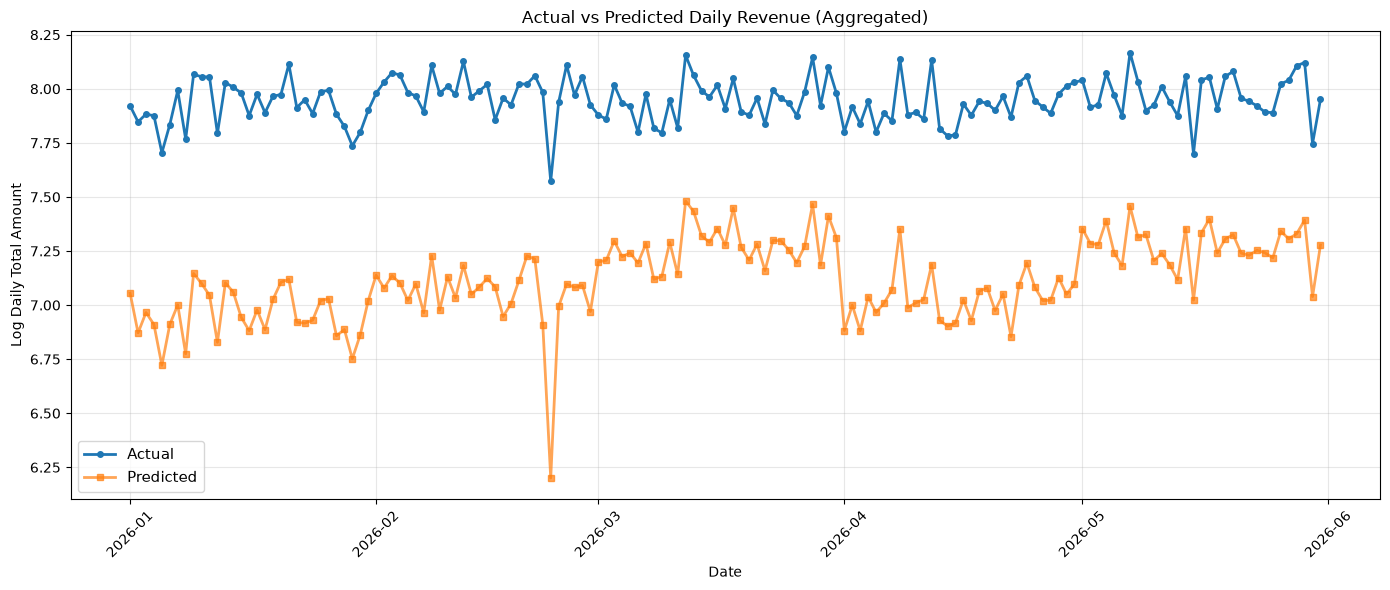

In [49]:
# Add predictions and actual values to test data
X_test_with_pred = pd.DataFrame({
    "date": test_data.select("date").toPandas()["date"],
    "y_actual": y_test.values,
    "y_pred": y_pred
})

# Aggregate by date
daily_actual = X_test_with_pred.groupby('date')['y_actual'].mean()
daily_pred = X_test_with_pred.groupby('date')['y_pred'].mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(daily_actual.index, daily_actual.values, label='Actual', linewidth=2, marker='o', markersize=4)
ax.plot(daily_pred.index, daily_pred.values, label='Predicted', linewidth=2, marker='s', markersize=4, alpha=0.7)

ax.set_xlabel('Date')
ax.set_ylabel('Log Daily Total Amount')
ax.set_title('Actual vs Predicted Daily Revenue (Aggregated)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

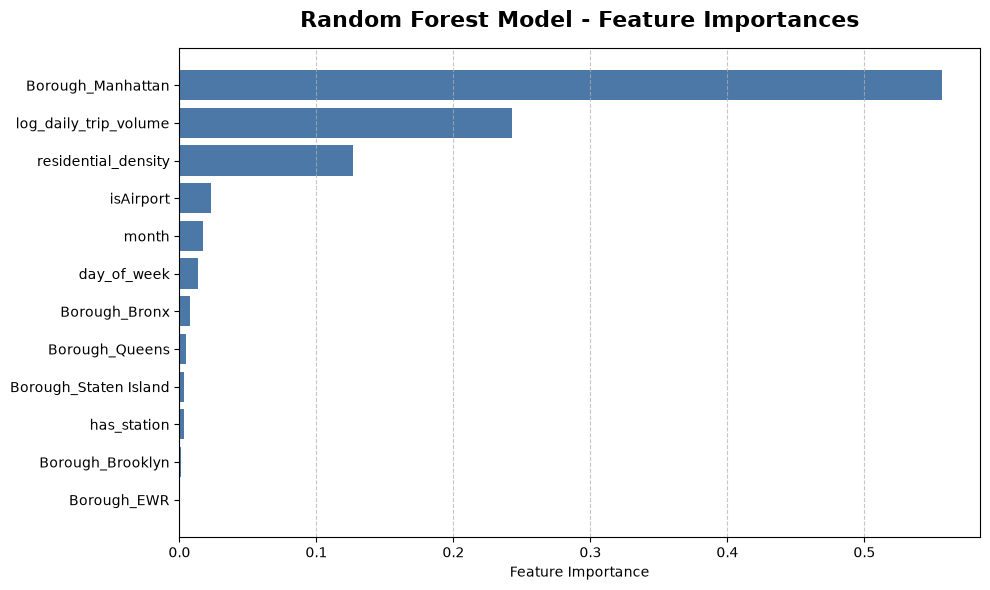

In [59]:
# Feature importance
rf_model = pipeline.named_steps['regressor']
feature_importances = rf_model.feature_importances_

# Get feature names after preprocessing
feature_names = numeric_features.copy()
# Add borough one-hot encoded names
encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat']
borough_names = [f"Borough_{b}" for b in encoder.categories_[0]]
feature_names.extend(borough_names)

# Create DataFrame and sort
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
importance_df_sorted = importance_df.sort_values('Importance')
plt.barh(importance_df_sorted['Feature'], importance_df_sorted['Importance'], color='#4C78A8')
plt.xlabel('Feature Importance')
plt.title('Random Forest Model - Feature Importances', fontsize=16, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
# save the plot as a PNG file
plt.savefig('images/feature_importances.png', dpi=300, bbox_inches='tight')
plt.show()

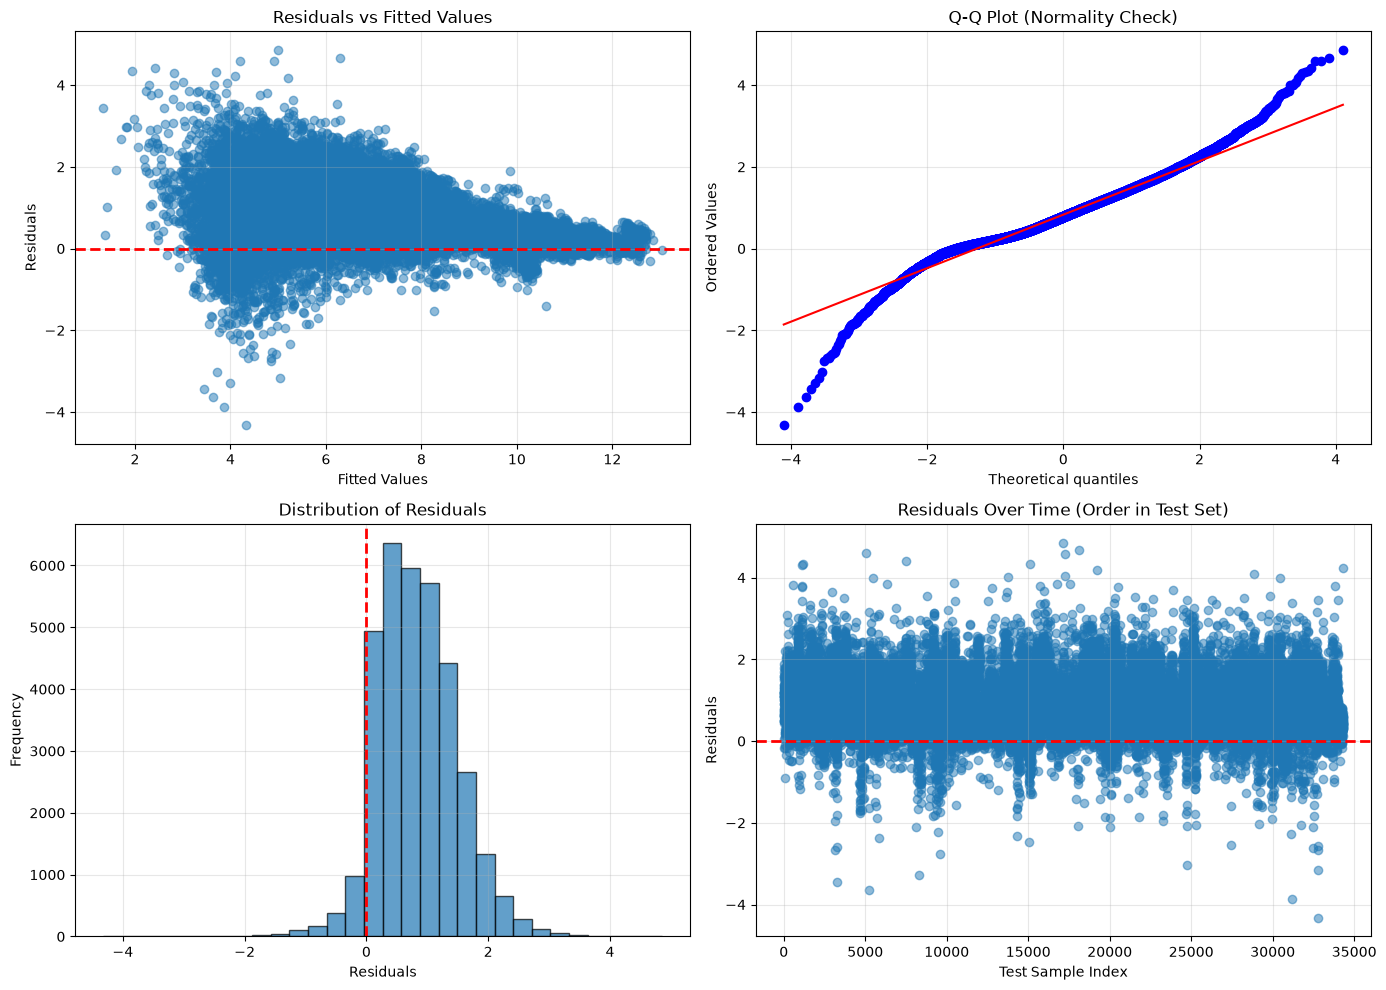

In [51]:
from scipy import stats

# Get predictions on test data
y_pred = pipeline.predict(X_test)
residuals = y_test.values - y_pred

# Create residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residuals vs Fitted Values
ax1 = axes[0, 0]
ax1.scatter(y_pred, residuals, alpha=0.5)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted Values')
ax1.grid(True, alpha=0.3)

# Plot 2: Q-Q Plot (check normality)
ax2 = axes[0, 1]
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Normality Check)')
ax2.grid(True, alpha=0.3)

# Plot 3: Histogram of residuals
ax3 = axes[1, 0]
ax3.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax3.set_xlabel('Residuals')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Residuals')
ax3.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax3.grid(True, alpha=0.3)

# Plot 4: Residuals over time (order in test set)
ax4 = axes[1, 1]
ax4.scatter(range(len(residuals)), residuals, alpha=0.5)
ax4.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax4.set_xlabel('Test Sample Index')
ax4.set_ylabel('Residuals')
ax4.set_title('Residuals Over Time (Order in Test Set)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model 2: Generalised least squares regression
We wanted one of our models to be a linear model. However, ordinary least squares (OLS) linear regression was not the right choice since our data was **temporal** and thus the residuals were likely to not be independent. Thus, we opted to use linear regression with generalised least squares (GLS) to work around this issue. GLS regression is perfectly suited for the temporal and time-dependent data that we are working with.

In this section, we train a GLS regression model on our training data, with the same features as what our random forest regressor was trained on. We then interpreted the model summary, in particular its coefficients and how they related to investigating what properties of a taxi zone affect daily revenue earnings the most.

We also observed some model diagnostic plots (particularly residuals to fitted values) to see whether there was any systematic patterns that the GLS model missed. 

Additionally, for the intentions of statistical inference, we observe the normal Q-Q plot to see whether the residuals of the model are approximately normally distributed. If this is not the case, we cannot reliably interpret the confidence intervals for the model or perform hypothesis tests.

In [52]:
training_data_final_copy = training_data_with_features_prefiltered
training_data_final_copy = training_data_final_copy.drop('PULocationID', 'daily_total_amount', 'daily_trip_volume', 'date', 'num_stations')
X_train_gls = training_data_final_copy.toPandas()
y_train_gls = X_train_gls.pop('log_daily_total_amount')

In [53]:
# One-hot encode the Borough column
borough_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_gls_encoded = borough_encoder.fit_transform(
    X_train_gls[['Borough']]
)

# Convert encoded Borough to a DataFrame
X_train_gls_encoded_df = pd.DataFrame(
    X_train_gls_encoded,
    columns=borough_encoder.get_feature_names_out(['Borough']),
    index=X_train_gls.index
)

# Remove original Borough column and concatenate encoded columns
X_train_gls_final = pd.concat(
    [
        X_train_gls.drop('Borough', axis=1),
        X_train_gls_encoded_df
    ],
    axis=1
)
# drop Borough_Manhattan column to avoid multicollinearity
X_train_gls_final = X_train_gls_final.drop('Borough_Manhattan', axis=1)
X_train_gls_final.head()

,residential_density,isAirport,log_daily_trip_volume,has_station,day_of_week,month,Borough_Bronx,Borough_Brooklyn,Borough_EWR,Borough_Queens,Borough_Staten Island
0,2.493068,0,6.556778,0,1,1,0.0,1.0,0.0,0.0,0.0
1,25.829412,0,6.810142,1,1,1,0.0,0.0,0.0,0.0,0.0
2,1.415681,0,8.018955,0,1,1,0.0,1.0,0.0,0.0,0.0
3,2.507860,0,7.451242,1,1,1,0.0,1.0,0.0,0.0,0.0
4,35.746736,0,8.149602,0,1,1,0.0,0.0,0.0,0.0,0.0


In [54]:
from statsmodels.regression.linear_model import GLS
gls_model = GLS(y_train_gls, X_train_gls_final)
results = gls_model.fit()
print(results.summary())

                                   GLS Regression Results                                  
Dep. Variable:     log_daily_total_amount   R-squared (uncentered):                   0.979
Model:                                GLS   Adj. R-squared (uncentered):              0.979
Method:                     Least Squares   F-statistic:                          1.034e+06
Date:                    Mon, 31 Aug 2026   Prob (F-statistic):                        0.00
Time:                            18:55:34   Log-Likelihood:                     -3.5789e+05
No. Observations:                  239385   AIC:                                  7.158e+05
Df Residuals:                      239374   BIC:                                  7.159e+05
Df Model:                              11                                                  
Covariance Type:                nonrobust                                                  
                            coef    std err          t      P>|t|      [0.025   

In [55]:
# print the MAE of the model
print(f"MAE: {mean_absolute_error(y_train_gls, results.fittedvalues):.4f}")

MAE: 0.8192


In [56]:
test_data_final = test_data
test_data_final = test_data_final.drop('date')
X_test_gls = test_data_final.toPandas()
y_test_gls = X_test_gls.pop('log_daily_total_amount')
# one hot encode the Borough column in the test set using the same encoder as the training set
X_test_gls_encoded = borough_encoder.transform(
    X_test_gls[['Borough']]
)   
X_test_gls_encoded_df = pd.DataFrame(
    X_test_gls_encoded,
    columns=borough_encoder.get_feature_names_out(['Borough']),
    index=X_test_gls.index
)
X_test_gls_final = pd.concat(
    [
        X_test_gls.drop('Borough', axis=1),
        X_test_gls_encoded_df
    ],
    axis=1
)
X_test_gls_final = X_test_gls_final.drop('Borough_Manhattan', axis=1)
X_test_gls_final.head(1)

,residential_density,isAirport,log_daily_trip_volume,has_station,day_of_week,month,Borough_Bronx,Borough_Brooklyn,Borough_EWR,Borough_Queens,Borough_Staten Island
0,2.588637,0,7.289611,1,6,5,0.0,1.0,0.0,0.0,0.0


In [57]:
preds = results.predict(X_test_gls_final)

# print metrics: r2, rmse, mae
rmse = mean_squared_error(y_test_gls, preds)
r2 = r2_score(y_test_gls, preds)
mae = mean_absolute_error(y_test_gls, preds)
print(f"GLS Model - Test Set Evaluation:\nRMSE: {rmse:.4f}\nR²: {r2:.4f}\nMAE: {mae:.4f}")

GLS Model - Test Set Evaluation:
RMSE: 1.5381
R²: 0.5928
MAE: 1.0834


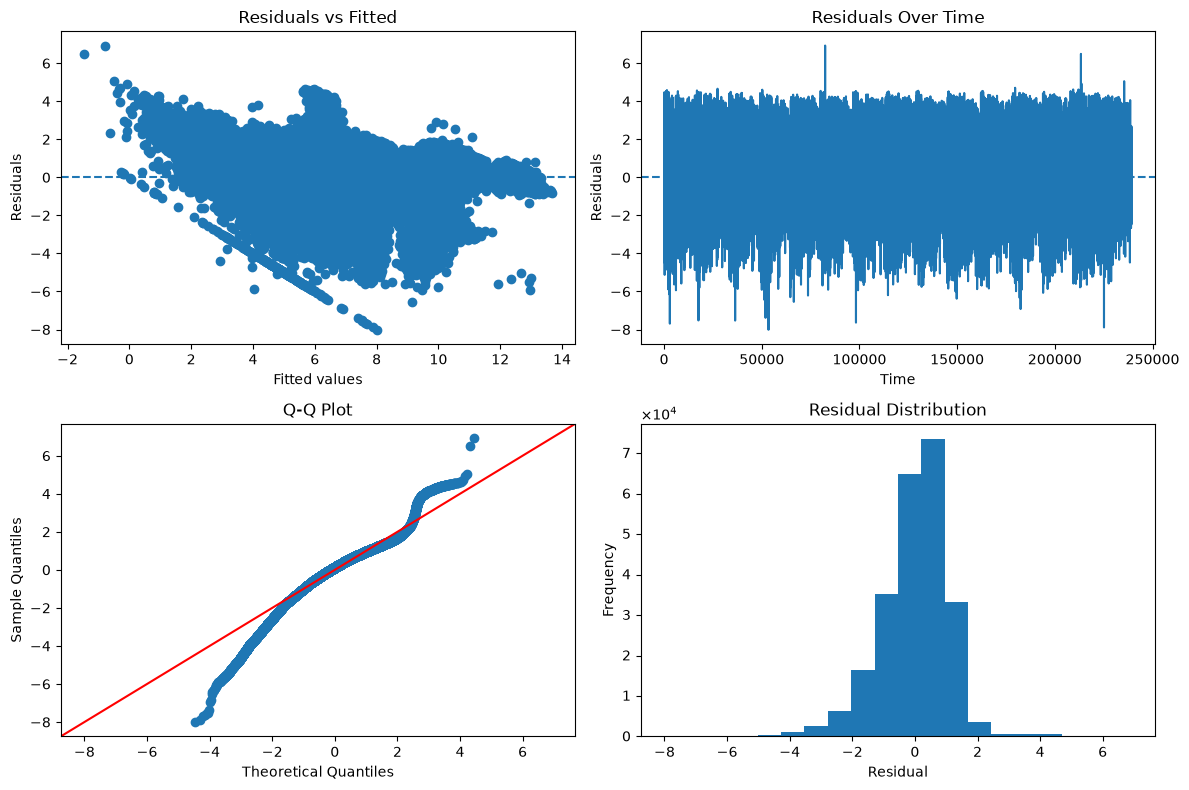

In [58]:
import statsmodels.api as sm
# import scalarformatter
from matplotlib.ticker import ScalarFormatter
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Residuals vs fitted
axes[0, 0].scatter(results.fittedvalues, results.resid)
axes[0, 0].axhline(0, linestyle="--")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

# Residuals over time
axes[0, 1].plot(results.resid)
axes[0, 1].axhline(0, linestyle="--")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("Residuals")
axes[0, 1].set_title("Residuals Over Time")

# Q-Q plot
sm.qqplot(results.resid, line="45", ax=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot")

# Histogram
axes[1, 1].hist(results.resid, bins=20)
axes[1, 1].set_xlabel("Residual")
axes[1, 1].set_title("Residual Distribution")
axes[1, 1].set_ylabel("Frequency")
# add scientific notation to the y-axis of the histogram
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
axes[1, 1].yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()